## Random Sample Imputation

Random sample imputation is a feature engineering technique used to handle missing data by replacing null values with randomly selected observations from the existing, non-missing data of the same variable.  Unlike mean or median imputation, this method does not calculate summary statistics; it directly samples the existing data distribution to fill the gaps.  It is most effective when data is **Missing Completely at Random (MCAR)**. 

***

## How It Works

If you have a dataset column with 10 missing values, the algorithm will:

1. **Isolate** all the non-missing values in that column.
2. **Randomly pick** 10 values from that pool.
3. **Insert** those 10 picked values into the empty spots. 

> No new numbers or categories are ever created. If the original data contains only the integers 22, 35, and 41, the imputed values will strictly be chosen from those numbers. 

***

## Direct Comparison: Random Sample vs. Mean/Median Imputation

| Feature / Metric          | Random Sample Imputation                                      | Mean / Median Imputation                                      |
|---------------------------|---------------------------------------------------------------|---------------------------------------------------------------|
| **Data Distribution**     | Preserves the shape and variance of the original distribution. | Distorts the distribution by creating a massive artificial spike at the center. |
| **Data Types Supported**  | Works perfectly for both numerical and categorical variables.  | Mostly restricted to numerical data (unless using mode for categorical). |
| **Reproducibility**       | Requires a random seed, otherwise results change every execution. | Naturally deterministic and remains the exact same every run. |
| **Variance Impact**       | Maintains natural variance but can introduce noise.            | Underestimates variance and errors by squeezing data toward the average. |

***

## Advantages and Disadvantages

### 🟢 Advantages

- **Preserves Distribution:** It keeps the overall variance and histogram shape intact, which is ideal for machine learning models sensitive to variance shifts. 
- **Easy to Implement:** It is computationally lightweight and easy to execute using standard libraries. 
- **No Outliers:** Because it only draws from existing entries, it will never introduce impossible or unexpected values. 

### 🔴 Disadvantages

- **Randomness:** Unless you explicitly set a `random_state` or seed, your machine learning models might produce different predictions every time the code runs. 
- **Breaks Covariance:** It ignores relationship patterns between columns. For example, if a missing "Salary" value belongs to an executive, random sampling might mistakenly replace it with an entry-level worker's salary. 
- **Poor for MAR/MNAR:** It does not perform well if the missingness depends on other variables (**Missing at Random**) or the variable itself (**Missing Not at Random**). 

***

In [1]:
# Raw Pandas Code
import pandas as pd
import numpy as np

In [41]:
# Create a sample dataset with missing values
df = pd.DataFrame({'Age':[22, 35, np.nan, 41, 19, np.nan, 50, 28]})

# Separate the non-missing values to create a "sampling pool"
non_na_pool = df['Age'].dropna()

# Count how many missing values need to be filled
num_missing = df['Age'].isnull().sum()

# Randomly sample from the pool (match the exact number of missing values)
# Note: random_staate ensures the code produces identical results every time it runs
random_samples = non_na_pool.sample(n = num_missing, random_state = 42, replace = True)

# Crucial step: Match the index of the random samples to the index of the missing values
random_samples.index = df[df['Age'].isnull()].index

# Fill the missing values using the indexed random samples
df['Age_imputed'] = df['Age'].fillna(random_samples)

In [44]:
df

,Age,Age_imputed
0,22.0,22.0
1,35.0,35.0
2,NaN,19.0
3,41.0,41.0
4,19.0,19.0
5,NaN,50.0
6,50.0,50.0
7,28.0,28.0


In [46]:
# Using feature engine
from feature_engine.imputation import RandomSampleImputer

df = pd.DataFrame({
    'Age': [22, 35, np.nan, 41, 19, np.nan, 50, 28],
    'Income': [45000, np.nan, 60000, 80000, np.nan, 52000, 95000, np.nan]
})

In [33]:
# Initialize the imputer 
# 'random_state' ensures reproducibility. 'variables' specifies columns (or leave it to aauto-detect)
imputer = RandomSampleImputer(variables=['Age', 'Income'], random_state=42)

# Fit and transform the dataset to learn the distribution pools form the data and to fill the missing vaalues
df_imputed = imputer.fit_transform(df)
df_imputed.columns = ['Age_imputed','Income_imputed']
result = pd.concat([df, df_imputed], axis = 1)
result

,Age,Income,Age_imputed,Income_imputed
0,22.0,45000.0,22.0,45000.0
1,35.0,NaN,35.0,52000.0
2,NaN,60000.0,19.0,60000.0
3,41.0,80000.0,41.0,80000.0
4,19.0,NaN,19.0,95000.0
5,NaN,52000.0,50.0,52000.0
6,50.0,95000.0,50.0,95000.0
7,28.0,NaN,28.0,80000.0


### Applied on a real dataset

In [121]:
df = pd.read_csv('train.csv', usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [122]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [123]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

In [124]:
X_train

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750
...,...,...
106,21.0,7.6500
270,NaN,31.0000
860,41.0,14.1083
435,14.0,120.0000


In [126]:
non_na_pool = X_train['Age'].dropna()
num_missing = X_train['Age'].isnull().sum()

random_samples = non_na_pool.sample(n = num_missing, random_state = 42, replace = True)
random_samples.index = X_train[X_train['Age'].isnull()].index

X_train['Age_imputed'] = X_train['Age'].fillna(random_samples)

In [127]:
X_train

,Age,Fare,Age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,54.0
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


In [129]:
num_missing_test = X_test['Age'].isnull().sum()

random_samples_test = non_na_pool.sample(n = num_missing_test, random_state = 42, replace = True)
random_samples_test.index = X_test[X_test['Age'].isnull()].index

X_test['Age_imputed'] = X_test['Age'].fillna(random_samples_test)

In [130]:
X_test

,Age,Fare,Age_imputed
709,NaN,15.2458,16.0
439,31.0,10.5000,31.0
840,20.0,7.9250,20.0
720,6.0,33.0000,6.0
39,14.0,11.2417,14.0
...,...,...,...
433,17.0,7.1250,17.0
773,NaN,7.2250,34.0
25,38.0,31.3875,38.0
84,17.0,10.5000,17.0


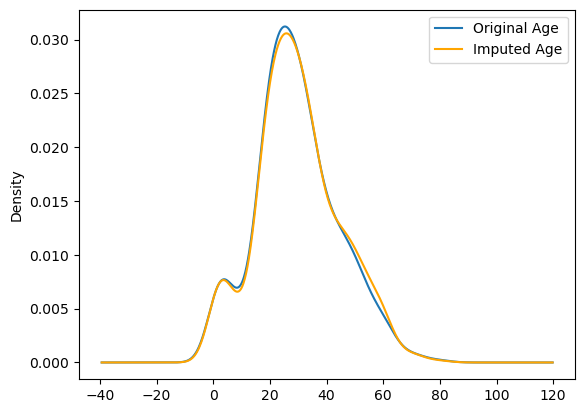

In [131]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Age'].plot(kind = 'kde', ax = ax)
X_train['Age_imputed'].plot(kind = 'kde', color = 'orange', ax = ax)

lines, labels = ax.get_legend_handles_labels()
labels = ['Original Age', 'Imputed Age']
ax.legend(lines, labels, loc = 'best')

plt.show()

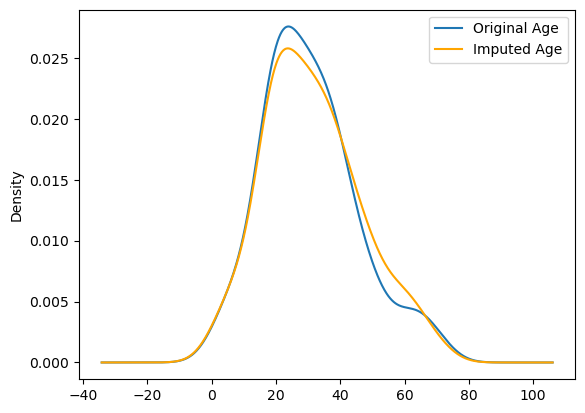

In [132]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111)

X_test['Age'].plot(kind = 'kde', ax = ax)
X_test['Age_imputed'].plot(kind = 'kde', color = 'orange', ax = ax)

lines, labels = ax.get_legend_handles_labels()
labels = ['Original Age', 'Imputed Age']
ax.legend(lines, labels, loc = 'best')

plt.show()

In [133]:
print(f'Original variable variance: {X_train['Age'].var()}')
print(f'Variance affter random imputation: {X_train['Age_imputed'].var()}')

Original variable variance: 210.2517072477438
Variance affter random imputation: 215.51367932410395


In [134]:
X_train[['Age','Fare','Age_imputed']].cov()

,Age,Fare,Age_imputed
Age,210.251707,71.580633,210.251707
Fare,71.580633,2700.831981,60.692205
Age_imputed,210.251707,60.692205,215.513679


<Axes: >

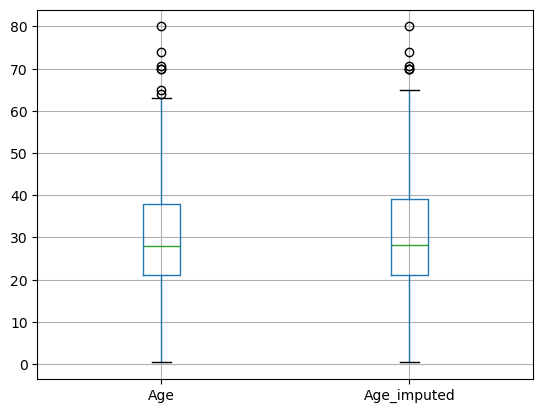

In [135]:
X_train[['Age','Age_imputed']].boxplot()

### Using Feature Engin

In [136]:
df = pd.read_csv('train.csv', usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [137]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [138]:
X = df.drop(columns = ['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [139]:
X_train.isnull().mean()

Age     0.196629
Fare    0.000000
dtype: float64

In [140]:
imputer = RandomSampleImputer(variables=['Age'], random_state=['Fare'], seed='observation', seeding_method = 'add')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

### Random Imputation for Categorical Data

In [158]:
data = pd.read_csv('train2.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [159]:
data.isnull().mean()

FireplaceQu    0.472603
GarageQual     0.055479
SalePrice      0.000000
dtype: float64

In [160]:
X = data
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [161]:
X_train.isnull().mean()

FireplaceQu    0.468322
GarageQual     0.054795
SalePrice      0.000000
dtype: float64

In [162]:
non_na_pool = X_train['FireplaceQu'].dropna()
num_missing = X_train['FireplaceQu'].isnull().sum()

random_sample = non_na_pool.sample(n = num_missing, random_state = 42, replace = True)

random_sample.index =X_train[X_train['FireplaceQu'].isnull()].index

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu'].fillna(random_sample)


# ------------------------------------------------------------------
num_missing_test = X_test['FireplaceQu'].isnull().sum()

random_sample_test = non_na_pool.sample(n = num_missing_test, random_state = 42, replace = True)

random_sample_test.index =X_test[X_test['FireplaceQu'].isnull()].index

X_test['FireplaceQu_imputed'] = X_test['FireplaceQu'].fillna(random_sample_test)

In [163]:
non_na_pool = X_train['GarageQual'].dropna()
num_missing = X_train['GarageQual'].isnull().sum()

random_sample = non_na_pool.sample(n = num_missing, random_state = 42, replace = True)

random_sample.index =X_train[X_train['GarageQual'].isnull()].index

X_train['GarageQual_imputed'] = X_train['GarageQual'].fillna(random_sample)


# ------------------------------------------------------------------
num_missing_test = X_test['GarageQual'].isnull().sum()

random_sample_test = non_na_pool.sample(n = num_missing_test, random_state = 42, replace = True)

random_sample_test.index =X_test[X_test['GarageQual'].isnull()].index

X_test['GarageQual_imputed'] = X_test['GarageQual'].fillna(random_sample_test)

In [164]:
temp = pd.concat([X_train['GarageQual'].value_counts()/len(X_train['GarageQual'].dropna()), X_train['GarageQual_imputed'].value_counts()/len(X_train)], axis = 1)
temp.columns = ['Original', 'Imputed']
temp

,Original,Imputed
TA,0.951087,0.952055
Fa,0.032609,0.032534
Gd,0.011775,0.011130
Ex,0.002717,0.002568
Po,0.001812,0.001712


In [165]:
temp = pd.concat([X_train['FireplaceQu'].value_counts()/len(X_train['FireplaceQu_imputed'].dropna()), X_train['GarageQual_imputed'].value_counts()/len(X_train)], axis = 1)
temp.columns = ['Original', 'Imputed']
temp

,Original,Imputed
Gd,0.261130,0.011130
TA,0.215753,0.952055
Fa,0.023116,0.032534
Ex,0.017979,0.002568
Po,0.013699,0.001712


C:\Users\HP\AppData\Local\Temp\ipykernel_48872\3949839757.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'], hist = False, label = category)
C:\Users\HP\AppData\Local\Temp\ipykernel_48872\3949839757.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457a

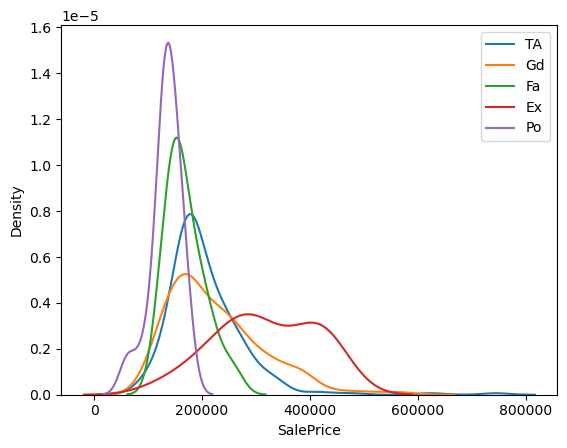

In [170]:
import seaborn as sns

for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'], hist = False, label = category)
    plt.legend()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_48872\1291225627.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'], hist = False, label = category)
C:\Users\HP\AppData\Local\Temp\ipykernel_48872\1291225627.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed

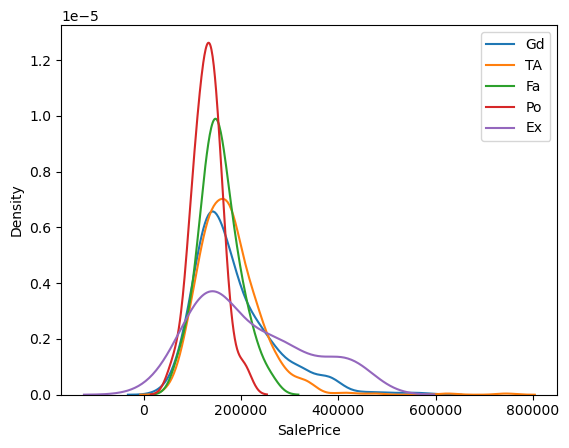

In [172]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'], hist = False, label = category)
    plt.legend()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_48872\2607991836.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['GarageQual'] == category]['SalePrice'], hist = False, label = category)
C:\Users\HP\AppData\Local\Temp\ipykernel_48872\2607991836.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad

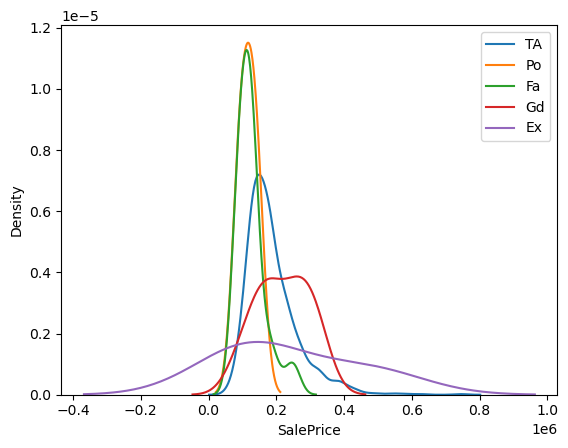

In [174]:
for category in X_train['GarageQual'].dropna().unique():
    sns.distplot(X_train[X_train['GarageQual'] == category]['SalePrice'], hist = False, label = category)
    plt.legend()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_48872\3960473915.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['GarageQual_imputed'] == category]['SalePrice'], hist = False, label = category)
C:\Users\HP\AppData\Local\Temp\ipykernel_48872\3960473915.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2

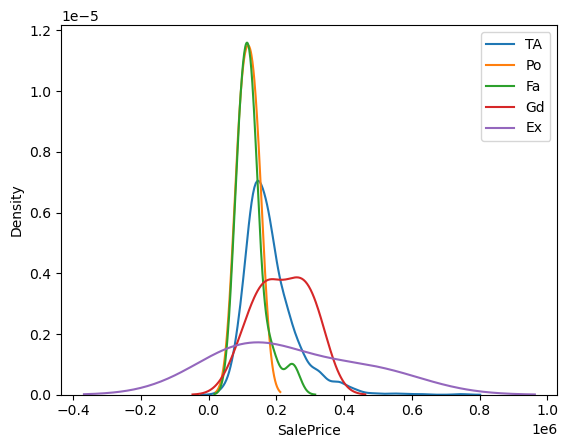

In [175]:
for category in X_train['GarageQual_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['GarageQual_imputed'] == category]['SalePrice'], hist = False, label = category)
    plt.legend()
plt.show()

### Using RandomSampleImputer

In [176]:
data = pd.read_csv('train2.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [177]:
X = data
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [195]:
imputer = RandomSampleImputer(variables = ['FireplaceQu', 'GarageQual'], random_state = ['SalePrice'], seed = 'observation', seeding_method = 'add')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [198]:
X_train_imputed

,FireplaceQu,GarageQual,SalePrice
254,Gd,TA,145000
1066,TA,TA,178000
638,Gd,TA,85000
799,TA,TA,175000
380,Gd,TA,127000
...,...,...,...
1095,Gd,TA,176432
1130,TA,TA,135000
1294,TA,TA,115000
860,Gd,TA,189950
